In [152]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler

from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder

In [153]:
df = pd.read_csv("Global_Pollution_Analysis.csv")

df.head()

,Country,Year,Air_Pollution_Index,Water_Pollution_Index,Soil_Pollution_Index,Industrial_Waste (in tons),Energy_Recovered (in GWh),CO2_Emissions (in MT),Renewable_Energy (%),Plastic_Waste_Produced (in tons),Energy_Consumption_Per_Capita (in MWh),Population (in millions),GDP_Per_Capita (in USD)
0,Hungary,2005,272.70,124.27,51.95,94802.83,158.14,5.30,41.11,37078.88,12.56,42.22,20972.96
1,Singapore,2001,86.72,60.34,117.22,56283.92,498.04,6.34,36.44,33128.20,5.23,137.25,34850.41
2,Romania,2016,91.59,83.36,121.72,56256.02,489.51,49.69,9.38,18803.46,13.15,124.47,57773.15
3,Cook Islands,2018,280.61,67.16,93.58,74864.73,145.18,8.91,18.97,9182.27,0.78,67.80,21837.51
4,Djibouti,2008,179.16,127.53,121.55,76862.06,40.38,14.93,34.00,39235.12,12.84,186.52,41379.37


In [154]:
df.columns = df.columns.str.replace(" ", "_", regex=False)
df.columns = df.columns.str.replace("(", "", regex=False)
df.columns = df.columns.str.replace(")", "", regex=False)
df.columns = df.columns.str.replace("%", "Percent", regex=False)

In [155]:
df.describe()

,Year,Air_Pollution_Index,Water_Pollution_Index,Soil_Pollution_Index,Industrial_Waste_in_tons,Energy_Recovered_in_GWh,CO2_Emissions_in_MT,Renewable_Energy_Percent,Plastic_Waste_Produced_in_tons,Energy_Consumption_Per_Capita_in_MWh,Population_in_millions,GDP_Per_Capita_in_USD
count,200.000000,200.00000,200.000000,200.000000,200.00000,200.000000,200.000000,200.000000,200.000000,200.00000,200.000000,200.000000
mean,2009.335000,180.62695,115.068100,76.488550,52891.68150,260.448700,24.878100,27.799700,24492.893550,9.43575,104.271300,35307.602400
std,5.765325,67.07331,47.580911,39.692727,27224.49169,147.141923,14.470892,12.361879,14421.356002,5.57567,56.906574,19481.714455
min,2000.000000,50.30000,31.130000,11.150000,1019.37000,11.730000,1.920000,5.040000,542.950000,0.53000,2.320000,1298.700000
25%,2004.000000,134.97250,74.550000,40.895000,31201.97250,118.355000,11.220000,17.700000,12843.882500,4.58250,60.960000,19525.020000
50%,2010.000000,183.38500,112.305000,78.600000,55299.15000,273.140000,25.355000,29.170000,24121.540000,9.22500,104.965000,35043.325000
75%,2014.000000,237.42500,157.477500,109.212500,74805.82500,384.957500,38.550000,37.072500,36516.232500,13.99750,150.930000,51629.547500
max,2019.000000,297.95000,199.320000,149.230000,99739.36000,499.980000,49.690000,49.560000,49852.280000,19.98000,198.820000,69143.140000


In [156]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 13 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Country                               200 non-null    str    
 1   Year                                  200 non-null    int64  
 2   Air_Pollution_Index                   200 non-null    float64
 3   Water_Pollution_Index                 200 non-null    float64
 4   Soil_Pollution_Index                  200 non-null    float64
 5   Industrial_Waste_in_tons              200 non-null    float64
 6   Energy_Recovered_in_GWh               200 non-null    float64
 7   CO2_Emissions_in_MT                   200 non-null    float64
 8   Renewable_Energy_Percent              200 non-null    float64
 9   Plastic_Waste_Produced_in_tons        200 non-null    float64
 10  Energy_Consumption_Per_Capita_in_MWh  200 non-null    float64
 11  Population_in_millions        

In [157]:
df = df.fillna(df.mean(numeric_only=True))

In [158]:
le = LabelEncoder()

df["Country"] = le.fit_transform(df["Country"])
df["Year"] = le.fit_transform(df["Year"])

In [159]:
scaler = StandardScaler()

pollution_cols = [
    "Air_Pollution_Index",
    "Water_Pollution_Index",
    "Soil_Pollution_Index"
]

df[pollution_cols] = scaler.fit_transform(df[pollution_cols])

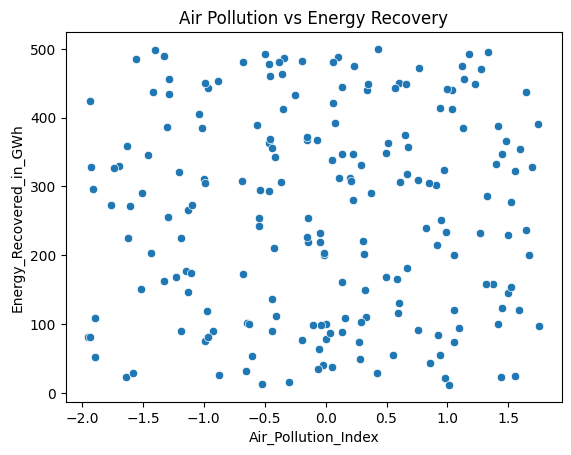

In [160]:
sns.scatterplot(
    x="Air_Pollution_Index",
    y="Energy_Recovered_in_GWh",
    data=df
)

plt.title("Air Pollution vs Energy Recovery")
plt.show()

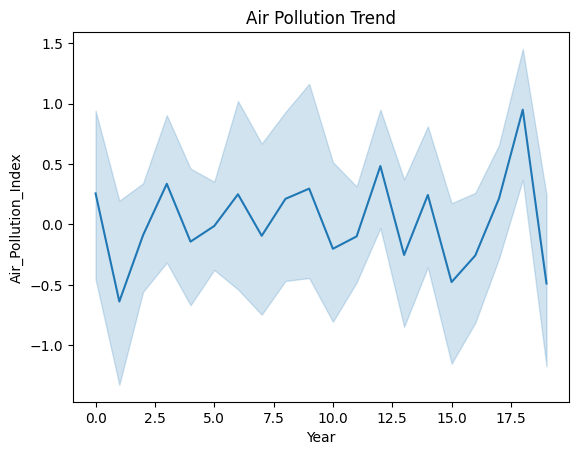

In [161]:
sns.lineplot(
    x="Year",
    y="Air_Pollution_Index",
    data=df
)

plt.title("Air Pollution Trend")
plt.show()

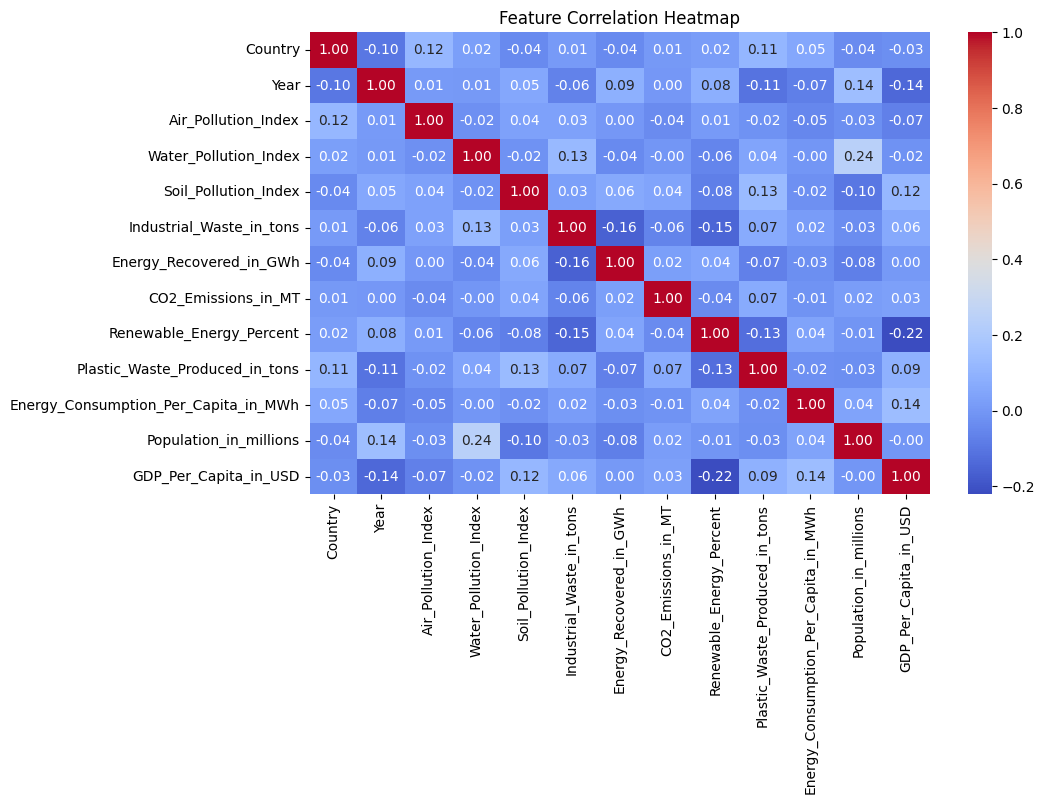

In [162]:
numeric_df = df.select_dtypes(include=[np.number])
plt.figure(figsize=(10,6))
corr = numeric_df.corr()
sns.heatmap(corr,annot=True,cmap="coolwarm",fmt=".2f"
)
plt.title("Feature Correlation Heatmap")
plt.show()

In [163]:
def pollution_level(x):
    if x < -0.5:
        return "Low_Air"
    elif x < 0.5:
        return "Medium_Air"
    else:
        return "High_Air"

df["Air_Level"] = df["Air_Pollution_Index"].apply(pollution_level)

In [164]:
def water_level(x):
    if x < -0.5:
        return "Low_Water"
    elif x < 0.5:
        return "Medium_Water"
    else:
        return "High_Water"

df["Water_Level"] = df["Water_Pollution_Index"].apply(water_level)

In [165]:
def energy_recovery_level(x):
    if x < df["Energy_Recovered_in_GWh"].quantile(0.33):
        return "Low_Energy"
    elif x < df["Energy_Recovered_in_GWh"].quantile(0.66):
        return "Medium_Energy"
    else:
        return "High_Energy"
    
df["Energy_Level"] = df["Energy_Recovered_in_GWh"].apply(energy_recovery_level)

def co2_level(x):
    if x < df["CO2_Emissions_in_MT"].quantile(0.33):
        return "Low_CO2"
    elif x < df["CO2_Emissions_in_MT"].quantile(0.66):
        return "Medium_CO2"
    else:
        return "High_CO2"

df["CO2_Level"] = df["CO2_Emissions_in_MT"].apply(co2_level)

transactions = df[
    ["Air_Level", "Water_Level", "Energy_Level", "CO2_Level"]
].values.tolist()

In [166]:
te = TransactionEncoder()

te_data = te.fit(transactions).transform(transactions)

df_apriori = pd.DataFrame(te_data, columns=te.columns_)

In [167]:
frequent_itemsets = apriori(
    df_apriori,
    min_support=0.01,
    use_colnames=True
)

frequent_itemsets.head()

,support,itemsets
0,0.340,frozenset({High_Air})
1,0.340,frozenset({High_CO2})
2,0.340,frozenset({High_Energy})
3,0.340,frozenset({High_Water})
4,0.305,frozenset({Low_Air})


In [175]:
rules = association_rules(
    frequent_itemsets,
    metric="confidence",
    min_threshold=0.3
)

print("Total rules:", len(rules))

rules = rules.sort_values(by="lift", ascending=False)

top_rules = rules.head(10)
top_rules

Total rules: 459


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
395,"frozenset({Low_Air, Medium_Water, High_Energy})",frozenset({Low_CO2}),0.010,0.330,0.010,1.000000,3.030303,1.0,0.006700,inf,0.676768,0.030303,1.000000,0.515152
346,"frozenset({Medium_Water, Medium_CO2})","frozenset({Medium_Energy, High_Air})",0.095,0.105,0.030,0.315789,3.007519,1.0,0.020025,1.308077,0.737569,0.176471,0.235519,0.300752
408,"frozenset({Medium_Water, High_Energy})","frozenset({Low_CO2, Medium_Air})",0.070,0.120,0.025,0.357143,2.976190,1.0,0.016600,1.368889,0.713978,0.151515,0.269481,0.282738
391,"frozenset({Low_Air, Medium_CO2})","frozenset({High_Water, High_Energy})",0.095,0.115,0.030,0.315789,2.745995,1.0,0.019075,1.293462,0.702578,0.166667,0.226881,0.288330
392,"frozenset({Low_Air, High_Energy})","frozenset({Medium_CO2, High_Water})",0.085,0.130,0.030,0.352941,2.714932,1.0,0.018950,1.344545,0.690346,0.162162,0.256254,0.291855
377,"frozenset({Low_Air, Medium_Water})","frozenset({Medium_Energy, High_CO2})",0.060,0.125,0.020,0.333333,2.666667,1.0,0.012500,1.312500,0.664894,0.121212,0.238095,0.246667
447,"frozenset({Low_CO2, Medium_Energy, Medium_Air})",frozenset({Medium_Water}),0.025,0.305,0.020,0.800000,2.622951,1.0,0.012375,3.475000,0.634615,0.064516,0.712230,0.432787
373,"frozenset({Medium_Energy, Medium_Water, High_C...",frozenset({Low_Air}),0.025,0.305,0.020,0.800000,2.622951,1.0,0.012375,3.475000,0.634615,0.064516,0.712230,0.432787
376,"frozenset({Low_Air, Medium_Water, High_CO2})",frozenset({Medium_Energy}),0.025,0.330,0.020,0.800000,2.424242,1.0,0.011750,3.350000,0.602564,0.059701,0.701493,0.430303
374,"frozenset({Medium_Energy, Medium_Water, Low_Air})",frozenset({High_CO2}),0.025,0.340,0.020,0.800000,2.352941,1.0,0.011500,3.300000,0.589744,0.057971,0.696970,0.429412


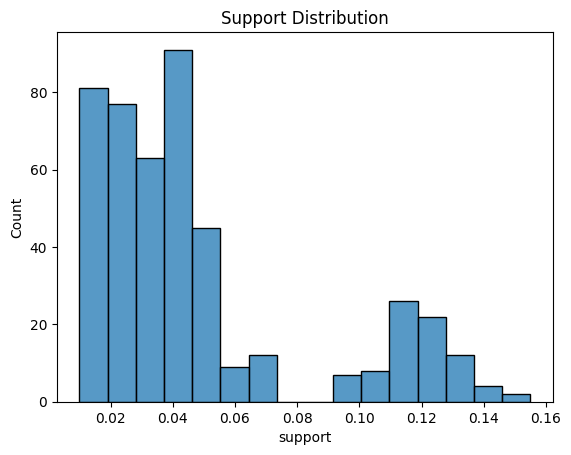

In [169]:
sns.histplot(rules["support"])

plt.title("Support Distribution")
plt.show()

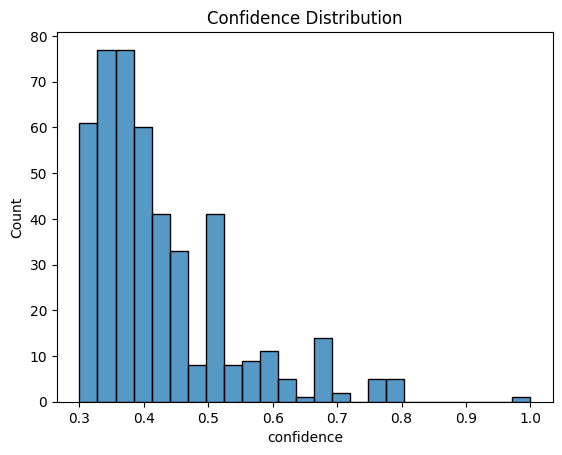

In [170]:
sns.histplot(rules["confidence"])

plt.title("Confidence Distribution")
plt.show()

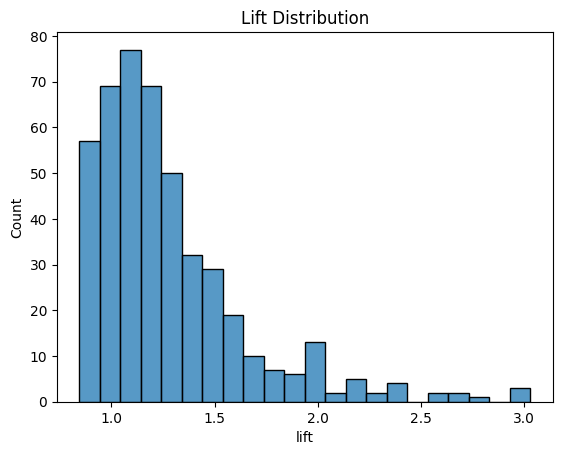

In [171]:
sns.histplot(rules["lift"])

plt.title("Lift Distribution")
plt.show()

In [172]:
print(frequent_itemsets.head())
print("Total frequent itemsets:", len(frequent_itemsets))

   support                  itemsets
0    0.340     frozenset({High_Air})
1    0.340     frozenset({High_CO2})
2    0.340  frozenset({High_Energy})
3    0.340   frozenset({High_Water})
4    0.305      frozenset({Low_Air})
Total frequent itemsets: 228


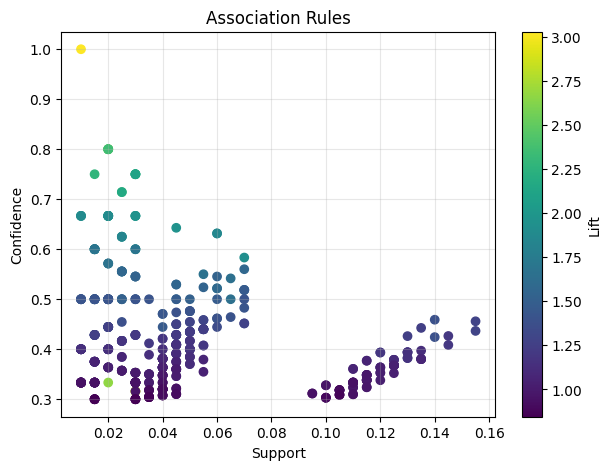

In [173]:
plt.figure(figsize=(7,5))

plt.scatter(
    rules["support"],
    rules["confidence"],
    c=rules["lift"],
    cmap="viridis"
)

plt.xlabel("Support")
plt.ylabel("Confidence")
plt.title("Association Rules")
plt.grid(True, alpha=0.3)
plt.colorbar(label="Lift")

plt.show()

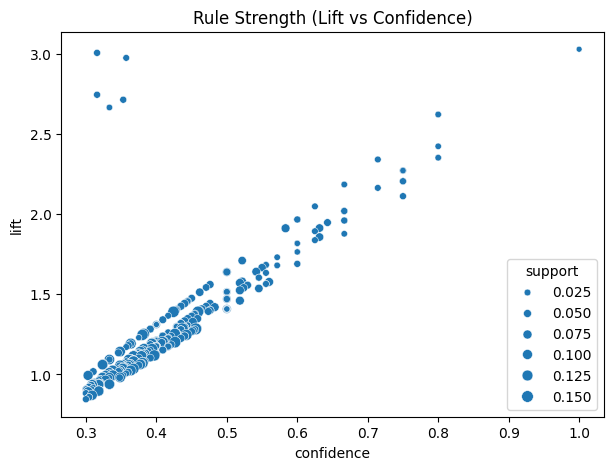

In [174]:
plt.figure(figsize=(7,5))

sns.scatterplot(
    x="confidence",
    y="lift",
    size="support",
    data=rules
)

plt.title("Rule Strength (Lift vs Confidence)")
plt.show()

## Overview

In this phase, the results obtained from the Apriori association rule mining process are evaluated and interpreted. The goal is to understand the patterns discovered between environmental pollution indicators and energy recovery levels. The evaluation focuses on identifying meaningful rules and validating their significance using key metrics such as support, confidence, and lift.

---

## Evaluation of Association Rules

The Apriori algorithm generated frequent itemsets and association rules based on the categorized environmental indicators. The rules were evaluated using three main metrics:

### Support
Support measures how frequently a rule appears in the dataset. A higher support value indicates that the rule occurs more often in the dataset.

### Confidence
Confidence measures how reliably the consequent occurs when the antecedent is present. Higher confidence values indicate stronger predictive relationships between the variables.

### Lift
Lift measures the strength of the association between the antecedent and the consequent relative to random occurrence. A lift value greater than 1 indicates a positive relationship between the variables.

---

## Validation of the Generated Rules

The generated rules were analyzed using distribution plots and scatter plots that visualize support, confidence, and lift values. These visualizations help in identifying the strongest rules within the dataset.

Rules with higher confidence and lift values were considered more significant, as they indicate stronger relationships between pollution levels and energy recovery patterns.

---

## Key Findings

The analysis revealed several important patterns in the dataset:

- Higher levels of air pollution frequently appear together with higher energy recovery levels.
- Moderate water pollution levels often correspond to moderate energy recovery patterns.
- Carbon emission levels also appear in several association rules, indicating their relationship with energy recovery activities.

These patterns suggest that environmental conditions may influence how energy recovery initiatives are implemented.

---

## Conclusion

The Apriori association rule mining approach successfully identified relationships between environmental pollution indicators and energy recovery levels. By analyzing the frequent itemsets and association rules, meaningful patterns were discovered within the dataset.

The evaluation using support, confidence, and lift metrics confirmed the strength and reliability of several rules. These results demonstrate how data mining techniques can be used to uncover hidden patterns in environmental datasets and support better environmental management strategies.